# Bagging y Random Forest

Vamos a analizar el funcionamiento de los métodos de Bagging:

- [Clasificación](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)
- [Regresión](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html)

y los de Random Forest: 

- [Clasificación](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
- [Regresión](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn-ensemble-randomforestregressor)

Veremos:

1. Ejemplo en clasificación
2. Ejemplo en regresión

Primero cargamos librerías y funciones necesarias:

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# 1. Ejemplo en clasificación

## 1.1 Exploración

En este primer ejemplo vamos a explorar el conjunto de datos para la detección de cancer de mama ([Breast Cancer](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29)). 

El objetivo es detectar si un cancer es benigno o maligno (B/N) a partir de la información de atributos numéricos que caracterizan los núcleos celulares de las imágenes digitalizadas de biopsias realizadas a distintos pacientes. La variable target es *diagnosis*, mientras que *id* es irrelevante.

<div class = "alert alert-success">
EJERCICIO 5.1: Cargue los datos almacenados en el fichero *breast_cancer.csv* y elimine las columnas *id* y *Unnamed: 32*. ¿Por qué aparece Unnamed? Echa un vistazo a los datos.
</div>

In [ ]:
data = pd.read_table('./data/breast_cancer.csv',sep=',', decimal='.')
data.head().T

In [ ]:
# ... código aquí
data = ...
data.head().T

Ahora vamos a ver cómo se distribuye la variable *diagnosis*:

In [ ]:
data['diagnosis'].value_counts()

Es categórica; vamos a convertirla en una variable numérica. Aquí tenemos varias opciones:

In [ ]:
# opción 1. np.where
data['label_opcion1'] = np.where(data['diagnosis'] == 'M',1,0)

# opción 2. LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(data['diagnosis'])

print(list(le.classes_))

data['label_opcion2'] = le.transform(data['diagnosis'])

data.head(20)

# hay muchas más opciones: onehot, ordinal, mean... 

Label Encoder tiene un problema muy fácil de cometer: si reutilizamos el mismo objeto para diferentes clases, sobreescribiremos las clases. Hay que evitarlo, porque el error es burdo. Una forma de hacerlo es:

In [ ]:
"""
le_var1 = preprocessing.LabelEncoder()
le_var1.fit(data['var1'])
data['var1_encoded'] = le_var1.transform(data['var1'])
print(list(le_var1.classes_))

le_var2 = preprocessing.LabelEncoder()
le_var2.fit(data['var2'])
data['var2_encoded'] = le_var2.transform(data['var2'])
print(list(le_var2.classes_))

##### en test

test_data['var1_encoded'] = le_var1.transform(test_data['var1'])
test_data['var2_encoded'] = le_var2.transform(test_data['var2'])
"""

En primer lugar conviene echar un vistazo a los datos. Como todos los datos son numéricos, un histograma puede ser una buena opción:

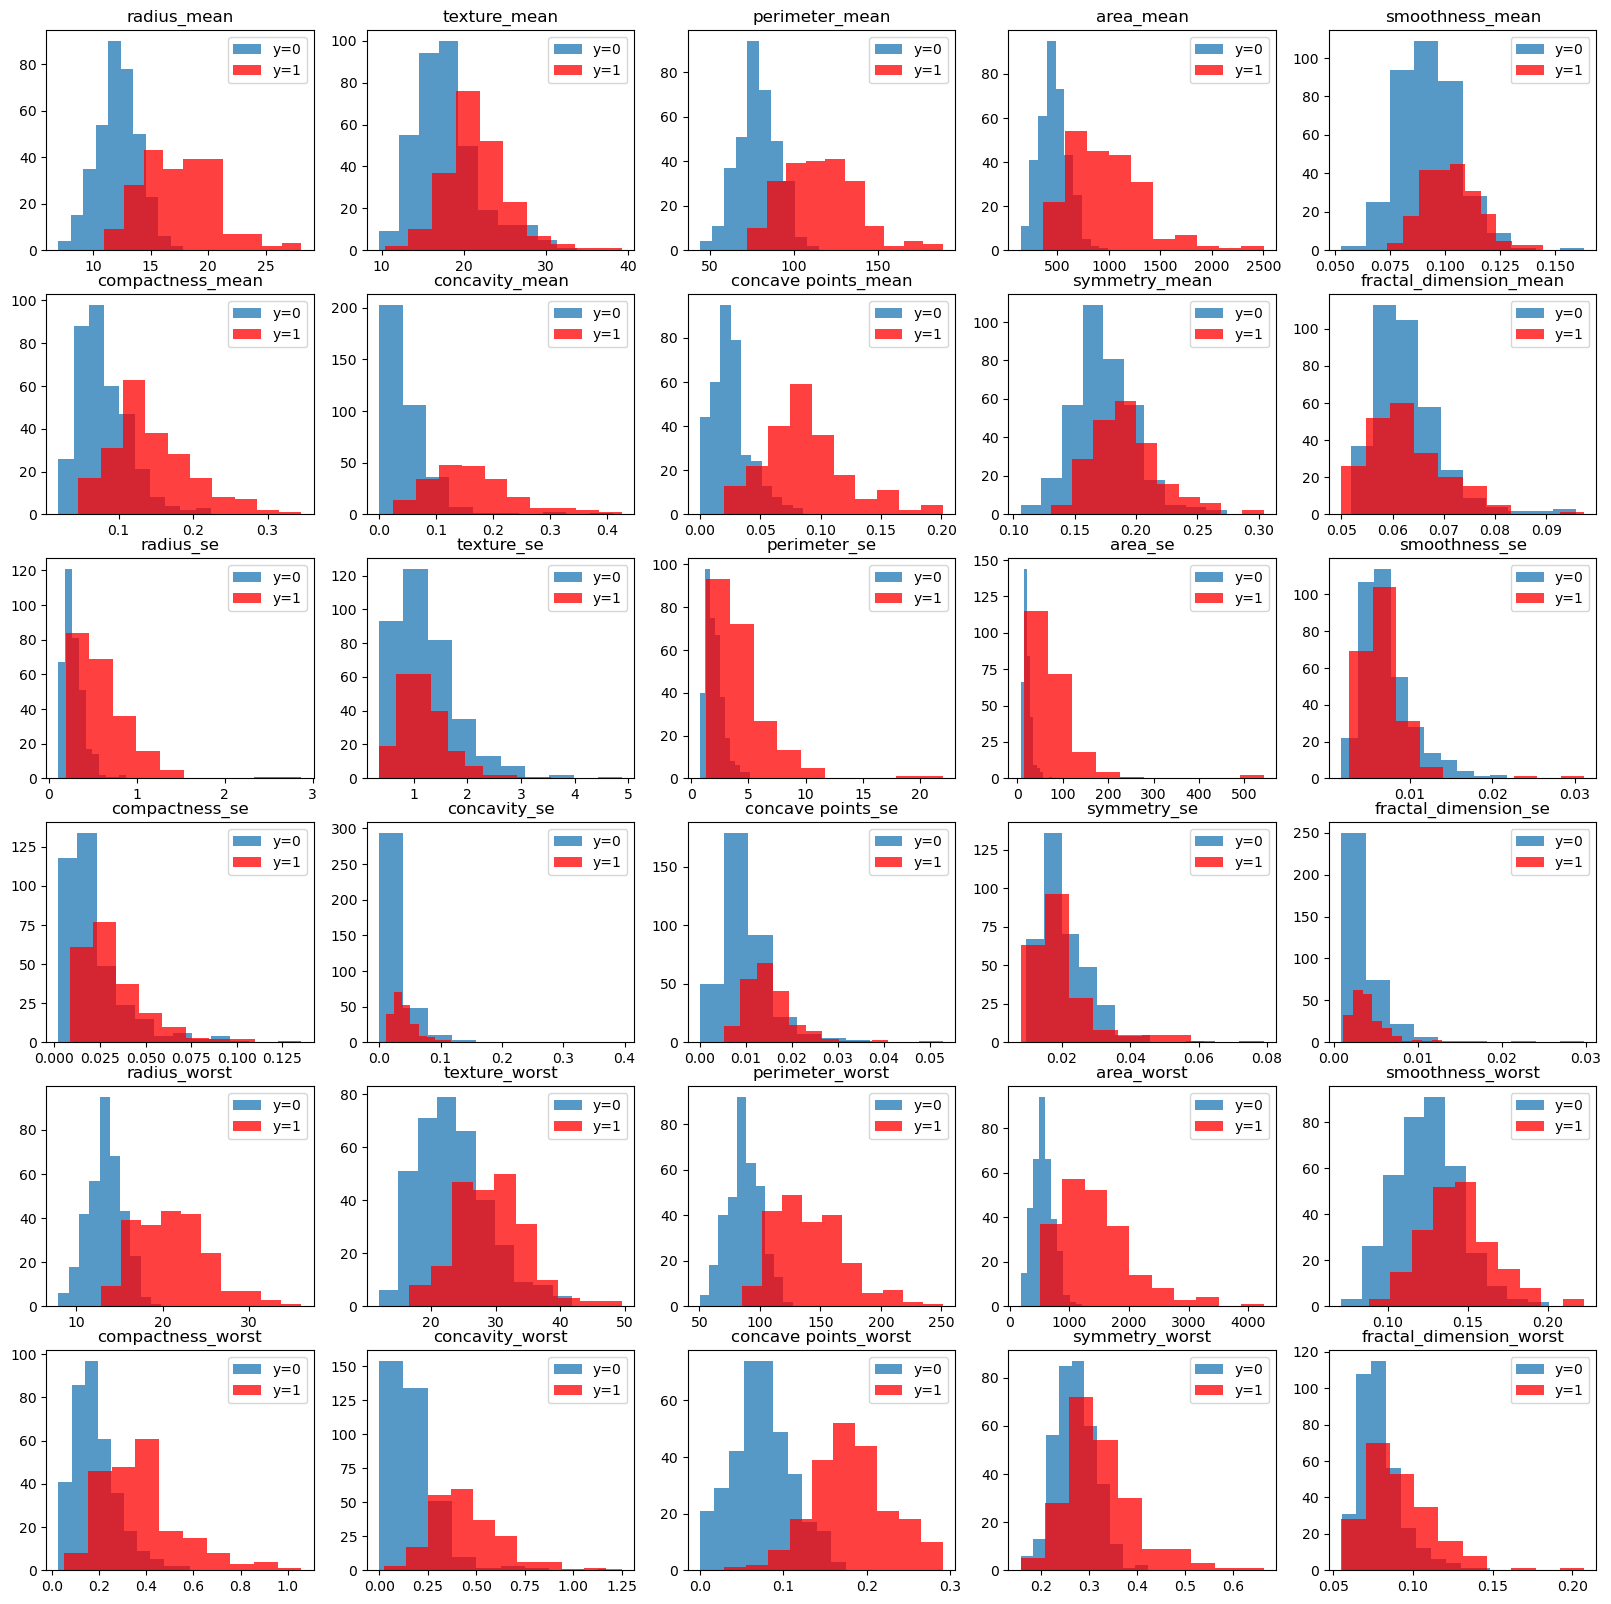

In [6]:
data = pd.read_table('./data/breast_cancer.csv',sep=',', decimal='.')
data =  data.drop(['id','Unnamed: 32'],axis=1)
data['diagnosis'] = np.where(data['diagnosis'] == 'M',1,0)

# Pintamos histogramas para cada clase
plt.figure(figsize=(20,20))

idx_0 =  data['diagnosis'] == 0
idx_1 =  data['diagnosis'] == 1

for i,feature in enumerate(data.columns.drop(['diagnosis'])):
    plt.subplot(6,5,i+1)   
    plt.hist(data.loc[idx_0,feature],density=0, alpha=0.75,label='y=0')
    plt.hist(data.loc[idx_1,feature],density=0, facecolor='red', alpha=0.75,label='y=1')
    plt.legend()
    plt.title(feature)

plt.show()

A la vista de los histogramas anteriores, podemos hacer transformaciones sobre las variables, para que el histograma se parezca más a una gaussiana. Esto se conoce como transformación de variables, y no modifican el resultado de la clasificación. Cuando tenemos distribuciones asimétricas (como por ejemplo *area_se*), podemos aplicar una transformación logarítmica o raíz cuadrada. ¡Cuidado! para transformar una variable hay que conocer el margen dinámico de la misma (no podemos aplicar logaritmos a valores negativos)

In [8]:
features_to_transform = ['radius_se','perimeter_se','area_se','compactness_se']

for feature in features_to_transform:
    data[feature] = data[feature].apply(lambda x: np.log10(x))

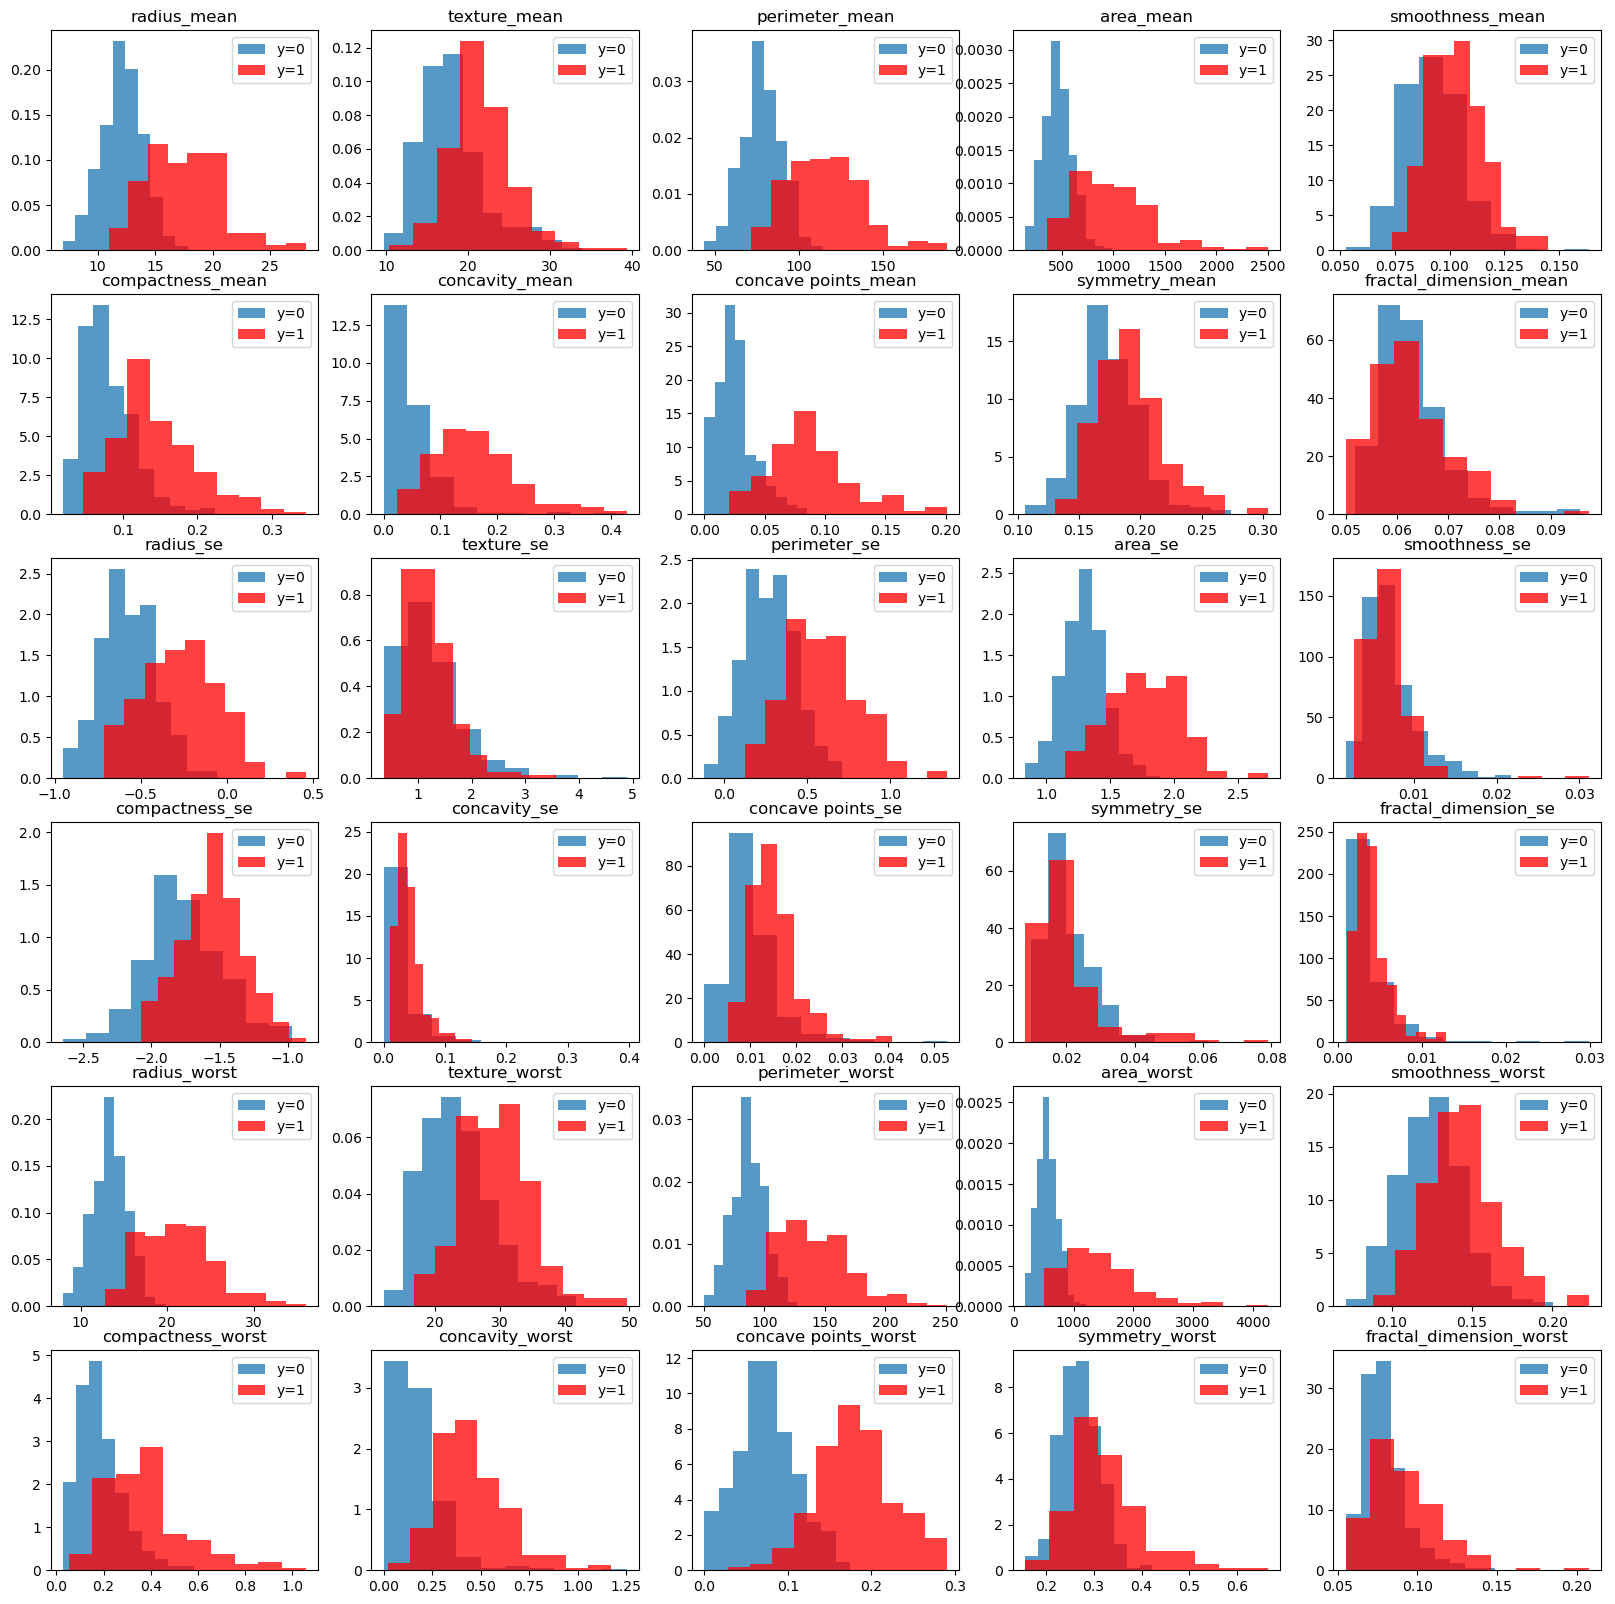

In [10]:
# Pintamos de nuevo histogramas para cada clase
plt.figure(figsize=(20,20))

idx_0 =  data['diagnosis'] == 0
idx_1 =  data['diagnosis'] == 1

for i,feature in enumerate(data.columns.drop(['diagnosis'])):
    plt.subplot(6,5,i+1)   
    plt.hist(data.loc[idx_0,feature],density=1, alpha=0.75,label='y=0')
    plt.hist(data.loc[idx_1,feature],density=1, facecolor='red', alpha=0.75,label='y=1')
    plt.legend()
    plt.title(feature)

plt.show()

Nota: como bien sabéis, esta división habría que hacerla al principio, no aquí; lo dejo así por no pasar por todo el proceso de generar dos ficheros, etc etc etc.

In [ ]:
from sklearn.model_selection import train_test_split

# preparamos los datos
features = data.columns.drop(['diagnosis'])
X = data[features].values
y = data['diagnosis'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

print('Datos train: ', X_train.shape)
print('Datos test:  ', X_test.shape)

## 1.2 Árbol de decisión individual

En primer lugar entrenamos un árbol individual para hacernos una idea de las prestaciones que alcanzamos.

<div class = "alert alert-success">
EJERCICIO 5.2: Entrena el árbol de decisión usando Grid Search.
</div>

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

maxDepth = range(1,10)
param_grid = {'max_depth': maxDepth }
# ... código aquí
grid = ...
grid.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth',fontsize=16)
plt.ylabel('10-Fold MSE')
#plt.ylim((-1, 0))
plt.show()

In [ ]:
maxDepthOptimo = grid.best_params_['max_depth']
treeModel = DecisionTreeClassifier(max_depth=maxDepthOptimo).fit(X_train,y_train)

print("Train: ",treeModel.score(X_train,y_train))
print("Test: ",treeModel.score(X_test,y_test))

In [ ]:
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(treeModel, feature_names=features, class_names=['B','M'], filled=True)

## 1.3 Bagging y Random Forest

Los parámetros libres de Bagging y Random forest son dos:

- Número de árboles construidos
- Complejidad de los mismos (normalmente max_depth o min_samples_leaf)

<div class = "alert alert-success">
EJERCICIO 5.3: Entrena un RandomForestClassifier usando Grid Search.
</div>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

maxDepth = range(1,15)
tuned_parameters = {'max_depth': maxDepth}

# ... código aquí
grid = ...
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [ ]:
maxDepthOptimo = grid.best_params_['max_depth']
randomForest = RandomForestClassifier(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt').fit(X_train,y_train)

print("Train: ",randomForest.score(X_train,y_train))
print("Test: ",randomForest.score(X_test,y_test))

<div class = "alert alert-success">
EJERCICIO 5.4: Entrena un BaggingClassifier usando Grid Search. Cuidado, que este es un poquito más difícil. Fijaos en el param grid; hay algo diferente.
</div>

In [ ]:
from sklearn.ensemble import BaggingClassifier

maxDepth = range(1,15)
tuned_parameters = {'base_estimator__max_depth': maxDepth}

# ... código aquí
grid = ...
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [ ]:
maxDepthOptimo = grid.best_params_['base_estimator__max_depth']
baggingModel = BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=maxDepthOptimo),n_estimators=200).fit(X_train,y_train)

print("Train: ",baggingModel.score(X_train,y_train))
print("Test: ",baggingModel.score(X_test,y_test))

## 1.4 Selección de características mediante la importancia de las variables


Una propiedad muy interesante de los algoritmos basados en árboles es que podemos medir la importancia de las variables. Vamos a probar los tres modelos previos:

### Árbol individual

In [ ]:
importances = treeModel.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),features[indices])
plt.show()

### Random Forest

In [ ]:
importances = randomForest.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),features[indices])
plt.show()

### Bagging Model

Ojo, Bagging de nuevo es diferente. Este código

```
importances = baggingModel.feature_importances_
```

no funciona, lo podéis probar. No existe feature_importances_ en Bagging en sklearn. ¿Por qué?

En Bagging, hay que hacer una media del atributo `feature_importances_` de cada uno de los árboles entrenados que contiene el modelo.

In [ ]:
importances = np.mean([tree.feature_importances_ for tree in baggingModel.estimators_], axis=0)
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),features[indices])
plt.show()

<div class = "alert alert-success">
EJERCICIO 5.5: Discutir y analizar las tres gráficas. ¿Los tres modelos funcionan igual de bien para extraer la importancia de las variables? ¿Por qué?
</div>

Utilizando este ranking, podemos hacer selección de características:

In [ ]:
from sklearn.model_selection import KFold

N,Nfeatures = X_train.shape

rf = RandomForestClassifier(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt')
kf  = KFold(n_splits=10, shuffle = True, random_state=1)
cv_error = []
cv_std = []

for nfeatures in range(Nfeatures,0,-1):
        
    error_i = []
    
    for idxTrain, idxVal in kf.split(X_train):
        
        Xt = X_train[idxTrain,:]
        yt = y_train[idxTrain]
        Xv = X_train[idxVal,:]
        yv = y_train[idxVal]
        
        rf.fit(Xt,yt)
        
        ranking = rf.feature_importances_
        indices = np.argsort(ranking)[::-1] 
    
        selected = indices[0:(Nfeatures-nfeatures+1)]
        
        Xs = Xt[:,selected]
        
        rf.fit(Xs,yt)
        error = (1.0-rf.score(Xv[:,selected],yv))     
        error_i.append(error) 
    
    cv_error.append(np.mean(error_i))
    cv_std.append(np.std(error_i))
    
    print('# features ' + str(len(selected)) + ' error ' + str(np.mean(error_i)) + ' +/- ' + str(np.std(error_i)))

In [ ]:
plt.plot(range(1,Nfeatures+1,1),cv_error,'-o')
plt.errorbar(range(1,Nfeatures+1,1), cv_error, yerr=cv_std, fmt='o')
plt.xlabel('# features')
plt.ylabel('CV error')
plt.show()

<div class = "alert alert-success">
EJERCICIO 5.6: Entrena un algoritmo de Random Forest con las características seleccionadas.
</div>

In [ ]:
# ... código aquí
selected_features = ...
randomForest = ...

print("Train: ",randomForest.score(X_train[:, selected_features],y_train))
print("Test: ",randomForest.score(X_test[:, selected_features],y_test))

También podemos pintar cuáles son las características seleccionadas:

In [ ]:
for sf in selected_features:
    print(features[sf])

# 2. Ejemplo en regresión

Vamos a usar el dataset que ya conocéis: King County. Vamos a hacer un árbol de decisión y un Random Forest y luego vosotros hacéis un BaggingRegressor.

In [ ]:
# cargamos datos
house_data = pd.read_csv("./data/kc_house_data.csv") # cargamos fichero

# Eliminamos las columnas id y date 
house_data = house_data.drop(['id','date'], axis=1)

# convertir las variables en pies al cuadrado en metros al cuadrado 
feetFeatures = ['sqft_living','sqft_lot','sqft_above','sqft_basement','sqft_living15','sqft_lot15']
house_data[feetFeatures] = house_data[feetFeatures].apply(lambda x: x * 0.3048 * 0.3048)

# renombramos
house_data.columns = ['price','bedrooms','bathrooms','sqm_living','sqm_lot','floors','waterfront','view','condition',
                      'grade','sqm_above','sqm_basement','yr_built','yr_renovated','zip_code','lat','long',
                      'sqm_living15','sqm_lot15']

# añadimos las nuevas variables
house_data['years']            = 2017 - house_data['yr_built']
house_data['bedrooms_squared'] = house_data['bedrooms'].apply(lambda x: x**2)
house_data['bed_bath_rooms']   = house_data['bedrooms']*house_data['bathrooms']
house_data['log_sqm_living']   = house_data['sqm_living'].apply(lambda x: np.log(x))
house_data['lat_plus_long']    = house_data['lat']*house_data['long']

house_data.head()

In [ ]:
# convertimos el DataFrame al formato necesario para scikit-learn
data = house_data.values 

y = data[:,0:1]     # nos quedamos con la 1ª columna, price
X = data[:,1:]      # nos quedamos con el resto

feature_names = house_data.columns[1:]

# Dividimos los datos en entrenamiento y test (80 training, 20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state = 2)

print('Datos entrenamiento: ', X_train.shape)
print('Datos test: ', X_test.shape)

## 2.1 Árbol de decisión

In [ ]:
from sklearn.tree import DecisionTreeRegressor

maxDepth = range(1,10)
param_grid = {'max_depth': maxDepth }
grid = GridSearchCV(DecisionTreeRegressor(random_state=0), param_grid=param_grid, cv = 3, verbose=2)
grid.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth',fontsize=16)
plt.ylabel('10-Fold MSE')
#plt.ylim((-1, 0))
plt.show()

In [ ]:
maxDepthOptimo = grid.best_params_['max_depth']
treeModel = DecisionTreeRegressor(max_depth=maxDepthOptimo).fit(X_train,y_train)

print("Train: ",treeModel.score(X_train,y_train))
print("Test: ",treeModel.score(X_test,y_test))

In [ ]:
from sklearn import tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(treeModel, feature_names=feature_names, filled=True)

In [ ]:
importances = treeModel.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

# 2.2 Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

maxDepth = range(1,15)
tuned_parameters = {'max_depth': maxDepth}

grid = GridSearchCV(RandomForestRegressor(random_state=0, n_estimators=200, max_features='sqrt'), param_grid=tuned_parameters,cv=3, verbose=2) 
grid.fit(X_train, y_train)

print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = np.array(grid.cv_results_['mean_test_score'])
plt.plot(maxDepth,scores,'-o')
plt.xlabel('max_depth')
plt.ylabel('10-fold ACC')

plt.show()

In [ ]:
maxDepthOptimo = grid.best_params_['max_depth']
randomForest = RandomForestRegressor(max_depth=maxDepthOptimo,n_estimators=200,max_features='sqrt').fit(X_train,y_train)

print("Train: ",randomForest.score(X_train,y_train))
print("Test: ",randomForest.score(X_test,y_test))

In [ ]:
importances = randomForest.feature_importances_
importances = importances / np.max(importances)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

# 2.3 Bagging regressor

<div class = "alert alert-success">
EJERCICIO 5.7: Entrena un algoritmo de bagging y devuelve las prestaciones para el conjunto de test
</div>

In [ ]:
from sklearn.ensemble import BaggingRegressor

# ... código aquí: GridSearch

In [ ]:
# ... código aquí: prestaciones en train y test

In [ ]:
# ... código aquí: importancia de las variables